In [1]:
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content="Please tell me how can I help", name="LLMModel")]
messages.append(HumanMessage(content="I want to learn coding", name="Krish"))
messages.append(AIMessage(content="Which programming language you want to learn", name="LLM Model"))
messages.append(HumanMessage(content="I want to learn python programming language", name="Krish"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLM Model

Which programming language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


In [2]:
from langchain_groq import ChatGroq
from langchain_groq import ChatGroq
from dotenv import find_dotenv
from dotenv import load_dotenv

def add(a: int, b: int) -> int:
    """Add a and b
    Args:
        a (int): first int
        b (int): second int
    Returns:
        int
    """
    return a + b

# Load environment variables (ensure GROQ_API_KEY is set in your .env)
load_dotenv(find_dotenv())

# Initialize Groq model
llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.7,
)

llm_with_tools = llm.bind_tools([add])
tool_call = llm_with_tools.invoke([HumanMessage(content="What is 2 plus 2", name="Krish")])
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'v0gnna2rn',
  'type': 'tool_call'}]

In [ ]:
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

initial_messages = [AIMessage(content="Please tell me how can I help", name="LLMModel")]
initial_messages.append(HumanMessage(content="I want to learn coding", name="Krish"))
ai_message = AIMessage(content="Which programming language you want to learn", name="LLMModel")
add_messages(initial_messages, ai_message)


[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='9d3407b4-2cdd-4745-86f0-5f8be8770a28', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish', id='a3909406-02a4-4a37-be26-255ff21637fc'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='d017b677-fbca-4b41-8f6a-f3b7e15dcf94', tool_calls=[], invalid_tool_calls=[])]

In [5]:
from langgraph.constants import END
from langgraph.constants import START
from langgraph.graph.state import StateGraph
import langgraph.graph.state

def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)
graph = builder.compile()
messages = graph.invoke({"messages": "What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (d15et6akw)
 Call ID: d15et6akw
  Args:
    a: 2
    b: 2


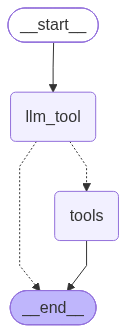

In [6]:
from langgraph.prebuilt import ToolNode, tools_condition

tools = [add]
builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "llm_tool")

builder.add_conditional_edges(
                                "llm_tool",
                                # tool call in last message -> "tools" ; otherwise -> END
                                tools_condition
                                )
                                
builder.add_edge("tools", END)
graph_builder = builder.compile()
graph_builder

In [ ]:
messages = graph.invoke({"messages": "What is 2 plus 2"})
messages["messages"]

[HumanMessage(content='What is 2 plus 2', additional_kwargs={}, response_metadata={}, id='145d2699-ac4a-4cee-a908-c41d436f52b5'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rh92fkmfs', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 311, 'total_tokens': 346, 'completion_time': 0.07757164, 'completion_tokens_details': None, 'prompt_time': 0.024825225, 'prompt_tokens_details': None, 'queue_time': 0.054184655, 'total_time': 0.102396865}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_4560dae850', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a87f-b121-7731-a11c-8b6ebafb80fa-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'rh92fkmfs', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 311, 'output_tokens': 35, 'total_tokens': 346}

In [11]:
messages = graph.invoke({"messages": "What Machine Learning"})
messages

{'messages': [HumanMessage(content='What Machine Learning', additional_kwargs={}, response_metadata={}, id='18f7610f-2d34-485b-b72d-d46ebe3a1558'),
  AIMessage(content='# What is Machine Learning?\n\n**Machine Learning (ML)** is a branch of **Artificial Intelligence (AI)** that enables computers to learn and improve from experience (data) without being explicitly programmed for every task.\n\n## Core Idea\nInstead of writing rules like *"if X, then Y"*, you provide the system with **data** and let it **discover patterns** on its own. The model learns a mapping from **inputs → outputs** by adjusting internal parameters to minimize prediction errors.\n\n## Main Types of ML\n\n| Type | Description | Example |\n|------|-------------|---------|\n| **Supervised Learning** | Learns from labeled data (input + correct output) | Spam detection, price prediction |\n| **Unsupervised Learning** | Finds patterns in unlabeled data | Customer segmentation, anomaly detection |\n| **Reinforcement Learni